# PROJEKT : <span style="margin-left:40px;"> Jerzy Marcin Urbański</span>

##### TEMAT:
## Analiza Jakości Powietrza Dla Wybranych Lokalizacji Oraz Okresów

<hr style="border: none; border-top: 11px dotted green;">

<hr style="border: none; border-top: 11px dotted green;">

Importy Bibliotek wraz z ich opisem 

In [5]:
# ### pandas

# Biblioteka do pracy z danymi tabelarycznymi (DataFrame), umożliwia łatwe filtrowanie, grupowanie i przekształcanie danych. 
# Używana głównie do analizy danych, czyszczenia danych oraz wczytywania/zapisywania plików (CSV, Excel, SQL).
import pandas as pd

# ### numpy
# Podstawowa biblioteka do obliczeń numerycznych w Pythonie, oferująca wydajne operacje na tablicach wielowymiarowych. 
# Wykorzystywana do obliczeń matematycznych, statystycznych oraz jako fundament dla innych bibliotek analitycznych.
import numpy as np

# ### os
# Biblioteka standardowa do interakcji z systemem operacyjnym, umożliwia pracę z plikami i katalogami oraz zmiennymi środowiskowymi. 
#Używana m.in. do automatyzacji operacji na plikach i zarządzania ścieżkami.
import os

# ### matplotlib
# Biblioteka do tworzenia wykresów i wizualizacji danych w Pythonie. Pozwala generować różne typy wykresów (liniowe, słupkowe, histogramy) 
# oraz dostosowywać ich wygląd.
import matplotlib.pyplot as plt

# ### seaborn
# Rozszerzenie matplotlib, które upraszcza tworzenie estetycznych i statystycznych wizualizacji danych. 
# Umożliwia szybkie generowanie wykresów takich jak heatmapy, wykresy rozkładu czy zależności między zmiennymi.
import seaborn as sns

# ### ydata_profiling
# Biblioteka do automatycznej analizy eksploracyjnej danych (EDA), generująca szczegółowe raporty o zbiorze danych. 
# Pokazuje statystyki, brakujące wartości, korelacje i potencjalne problemy w danych.
from ydata_profiling import ProfileReport

# ### IPython.display
# Moduł umożliwiający wyświetlanie różnych typów treści w notebookach (HTML, obrazy, wideo). 
#  Używany do wzbogacania prezentacji wyników analiz i tworzenia interaktywnych raportów.
from IPython.display import IFrame

# Moduł do obsługi ścieżek plików
from pathlib import Path

# Moduł do obliczania macirzy korelacji miedzy zmiennymi DataFrame , zarówno numerycznymi jak i kategorycznymi 
from phik import phik_matrix

Sekcja bibliotek ML

In [660]:
# import....

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, FunctionTransformer

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import cross_val_score

from sklearn.dummy import DummyRegressor



from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor 
# pip install xgboost lightgbm
from xgboost import XGBRegressor
from catboost import CatBoostRegressor
from lightgbm import LGBMRegressor
from sklearn.multioutput import MultiOutputRegressor


## STEP 1. DANE SUROWE - Wczytanie + przygotowanie.
        [ LOAD DATA + PREPROCESSING NA WSTĘPNYCH DANYCH ]
Import danych z plików csv , ostateczne sprawdznie oraz potrzebna agregacja do ostatecznej wersji.

### 1.1. Dane pogodowe - weather_[..].csv


In [11]:
# import wszyskich plików do odpowiednich zmiennych 

w_pz_2021 = pd.read_csv('/Users/marcinurbanski/Desktop/jmu_repo/1_projekt_air_polution_repo/0_ready_raw_data/weather_pz_2021.csv')
w_pz_2022 = pd.read_csv('/Users/marcinurbanski/Desktop/jmu_repo/1_projekt_air_polution_repo/0_ready_raw_data/weather_pz_2022.csv')
w_pz_2023 = pd.read_csv('/Users/marcinurbanski/Desktop/jmu_repo/1_projekt_air_polution_repo/0_ready_raw_data/weather_pz_2023.csv')
w_pz_2024 = pd.read_csv('/Users/marcinurbanski/Desktop/jmu_repo/1_projekt_air_polution_repo/0_ready_raw_data/weather_pz_2024.csv')

In [12]:
# szybkie sprawdznie 

# display(w_pz_2021.head(2))
display(w_pz_2022.head(2))
# display(w_pz_2023.head(2))
# display(w_pz_2024.head(2))

,Unnamed: 0,time,latitude,longitude,number,step,surface,valid_time,u10,v10,t2m,blh,sp,tcc
0,0,2022-01-01 00:00:00,52.5,17.0,0,0 days,0.0,2022-01-01 00:00:00,5.818466,-0.939590,283.89478,766.70337,100318.06,1.0
1,1,2022-01-01 06:00:00,52.5,17.0,0,0 days,0.0,2022-01-01 06:00:00,5.129639,-1.196472,283.35474,739.45680,100606.81,1.0


#### 1.1.1. Połaczenie w jedne DataFrame

In [14]:
w_df = pd.concat([w_pz_2021,w_pz_2022,w_pz_2023,w_pz_2024], axis=0 , ignore_index=True)

#### 1.1.2. - Agregacja danych do postaci uniwersalnego DataFrame 

In [16]:
# przypisanie odpowiedniego id miasta [city] wg współrzędnych

w_df['city'] = w_df['longitude'].map({17.0 : 'PZ'})

In [17]:
# Selekscja kolumn do usunięcia 

# print(w_pz_2021['step'].nunique()) # kolumna ma jeden wynik -> usunać
# print('-'*140)
# print(w_pz_2022['surface'].nunique()) # kolumna ma jeden wynik -> usunać
# print('-'*140)
# print(w_pz_202[w_ld_2004["time"] != w_ld_2004["valid_time"]]) # kolumna 'valid_time' powtrza wartosci 'time' -> usunać 
# print('-'*140)
# print(w_ld_2012['number'].nunique())

In [18]:
# usunięcie niepotrzebnych kolumn ['Unnamed: 0','latitude','longitude','step','surface','valid_time']

w_df = w_df.drop(['Unnamed: 0','latitude','longitude','step','surface','valid_time','number'], axis=1)

In [19]:
# Zamiana typu danych object z kolumny 'time' na date_time

w_df['time'] = pd.to_datetime(w_df['time'])

Obliczenie prędkości wiatru ze zmiennych u10 & v10 ze wzoru tj z równania pitagorasa
- zmienna u10 => prędkość wiatru zachodniego 
- zmienna v10 => prędkość wiartu północnego 

$$
v_w = \sqrt{u_{10}^2 + v_{10}^2}
$$


In [21]:
# przeliczenie prędkości wiatru 'v_w' i dodanie jako nowa kolumna z tymi wartościami

w_df['v_w'] = np.sqrt(w_df['u10']**2 + w_df['v10']**2)

In [22]:
# Usunicie zbędnych kolumn u10, 'v10' jako składowe wiatru nie potrzebne do dalszych analiz.

w_df = w_df.drop(['u10','v10'], axis=1)

In [23]:
# ułożenie kolejnosci kolumn [info data | zmienne pogodowe] 

col_order = ['city','time','v_w','t2m','blh','sp','tcc']
w_df = w_df[col_order]

#### 1.1.3. PODSUMOWANIE PKT. 1.1 DANE POGOWE 
OPIS ZMIENNYCH 
- 'city' -> MIASTO ZAPISANE W SYMOBOLEM
    - PZ = Poznań
    - LD = Łódź 
- 'time'............ DATA GODZINA
- 'u10' -> predkosc wiatru z kierunku / jednostko = [ m/s ] 
- 'v10' -> prędkość wiatru z kierunku / jednostka = [ m/s ]
- 'v_w' -> rzeczywista prędkość wiatru / jednostka = [ m/s ]
- 't2m' -> temperatura powietrze 2m nad poziomem powierzchni / jednostka [ Kelwin ]
- 'blh' -> WYSOKOŚĆ WARSTWY GRANICZNEJ / jednostka [ m ]
- 'sp' -> CIŚNIENIE / jednostka [ Pa ]
- 'tcc' -> CAŁKOWITE ZACHMURZENIE / jednostk [ 0-1 ] [ % ]

    

### 1.2. TABELE CAŁKOWITE OPADY - total_precipition

#### 1.2.1. Import wszyskich plików do odpowiednich zmiennych 

In [27]:
tp_pz_2021 = pd.read_csv('/Users/marcinurbanski/Desktop/jmu_repo/1_projekt_air_polution_repo/0_ready_raw_data/total_precipitation_pz_2021.csv')
tp_pz_2022 = pd.read_csv('/Users/marcinurbanski/Desktop/jmu_repo/1_projekt_air_polution_repo/0_ready_raw_data/total_precipitation_pz_2022.csv')
tp_pz_2023 = pd.read_csv('/Users/marcinurbanski/Desktop/jmu_repo/1_projekt_air_polution_repo/0_ready_raw_data/total_precipitation_pz_2023.csv')
tp_pz_2024 = pd.read_csv('/Users/marcinurbanski/Desktop/jmu_repo/1_projekt_air_polution_repo/0_ready_raw_data/total_precipitation_pz_2024.csv')

In [28]:
# szybkie sprawdznie 

# print(tp_pz_2021.info())
# print('^'*140)
# display(tp_pz_2021.head(10))
# display(tp_pz_2022.head(2))
# display(tp_pz_2023.head(2))
# display(tp_pz_2024.head(2))

####  1.2.2. Połaczenie wszystkich Data Frame w jeden pogodowy 

In [30]:
tp_df = pd.concat([tp_pz_2021,tp_pz_2022,tp_pz_2023,tp_pz_2024], axis=0 , ignore_index=True).reset_index()

#### 1.2.3. - Agregacja danych do postaci uniwersalnego DataFrame 

In [32]:
# usuwamy zbedne kolumny, nie potrzebne do analizy i dalszej agregacji 

tp_df = tp_df.drop(['Unnamed: 0','time','step','number','surface','index'], axis=1) 

In [33]:
# Zamiana kolumn z data i czasem na typ danych date_time

tp_df['valid_time'] =  tp_df['valid_time'].apply(pd.to_datetime)

# Usuwamy niepotrzebne punkty pomiarowe z innych godzin 'valid_time' niż 00:00, 06:00, 12:00, 18:00 każdego dnia

tp_df = tp_df[tp_df['valid_time'].dt.hour.isin([0, 6, 12, 18])]

# zamieniamy nazwę valid_time na time , aby pasowała do poprzedniego DataFrame dane pogodowe i mozliwosci ich połaczenia

tp_df = tp_df.rename(columns={'valid_time':'time'})

In [34]:
# sprawedzenie wartosci longitude dla wybranych miast 
tp_df['longitude'].unique()

array([17.])

In [35]:
# przypisanie skrótu miasta w nowej kolumnie 'city' + usuniecie niepotrzebnej kolu

tp_df['city'] = tp_df['longitude'].map({17.0 : 'PZ'})

In [36]:
# usuwamy zbedne kolumny lognitude i 

tp_df = tp_df.drop(['longitude','latitude'], axis=1) 

In [37]:
# Sprawdzenie 
# tp_df.describe()

#### 1.2.4. PODSUMOWANIE PKT. 1.2. CAŁKOWITE OPADY  
OPIS ZMIENNYCH 
- 'PZ' -> MIASTO ZAPISANE W SYMOBOLEM
    - PZ = Poznań
    - LD = Łódź
- 'time'............ DATA GODZINA
- 'tp' -> CAŁKOWITE OPADY / jednostka [ m ] - skumulowany opad 

### 1.3. TABELE INWERSJE - inwesrsja [..].csv

#### 1.3.1. Import wszystich plikow do odpowiednich zmienych 

In [41]:
i_pz_2021 = pd.read_csv('/Users/marcinurbanski/Desktop/jmu_repo/1_projekt_air_polution_repo/0_ready_raw_data/inwersja_pz_2021.csv')
i_pz_2022 = pd.read_csv('/Users/marcinurbanski/Desktop/jmu_repo/1_projekt_air_polution_repo/0_ready_raw_data/inwersja_pz_2022.csv')
i_pz_2023 = pd.read_csv('/Users/marcinurbanski/Desktop/jmu_repo/1_projekt_air_polution_repo/0_ready_raw_data/inwersja_pz_2023.csv')
i_pz_2024 = pd.read_csv('/Users/marcinurbanski/Desktop/jmu_repo/1_projekt_air_polution_repo/0_ready_raw_data/inwersja_pz_2024.csv')

In [42]:
# szybkie sprawdzenie 

# print(i_pz_2021.info())
# print('^'*140)
# display(i_pz_2021.head(2))
# display(i_pz_2022.head(2))
# display(i_pz_2023.loc[i_pz_2023['time']=='2023-04-23 18:00:00'])
# display(i_pz_2024.head(2))

#### 1.3.2. Łaczymy wszyskie tabele do jednego DataFrame

In [44]:
i_df = pd.concat([i_pz_2021, i_pz_2022, i_pz_2023, i_pz_2024],  axis=0, ignore_index=True)

#### 1.3.3. Agregacja danych do postaci uniwersalnego datasetu.

In [46]:
# przypisanie skrótu miasta w nowej kolumnie 'city' + usuniecie niepotrzebnej kolu

i_df['city'] = i_df['longitude'].map({17.0 : 'PZ'})

In [47]:
# Zamiana typu danych kolumny 'time' na date_time

i_df['time'] = pd.to_datetime(i_df['time'])

In [48]:
## USTALENIE INWERSJI 0/1 NA PODSTAWIE RÓŻNICY TEMPERATURY NA WYSOKOŚĆI Z CIŚNIENEIM 1000 A 925

# Rozdzielam na dwa DataFrame 
df_925 = i_df[i_df['isobaricInhPa'] == 925][['time','t','city']].rename(columns = {'t': 't_925'})
df_1000 = i_df[i_df['isobaricInhPa'] == 1000][['time','t','city']].rename(columns = {'t': 't_1000'})

# Łaczymy oba df, w jeden do obliczenia różnicy
i_df_delta = pd.merge(df_925, df_1000, how='left', on=['time','city'])

# kolumna t_delta = podaje rożnice w stopniach 
i_df_delta['t_delta'] = i_df_delta['t_1000']-i_df_delta['t_925']
i_df_delta['inversion_0/1'] = [1 if e > 0 else 0 for e in i_df_delta['t_delta']]

# i_df_delta.head()

In [49]:
# usuwamy nie potrzebne kolumny do dalszej analizy 

i_df_delta = i_df_delta.drop(['t_925','t_1000','t_delta'],axis=1)

In [50]:
# Sprawdzenie poprawnosci inwersja_DataFrame gotowego do megre do głwnego DataFrame

display(i_df_delta.iloc[1000:1010])
print('^' * 140) 
display(i_df_delta['city'].unique())
display(i_df_delta['inversion_0/1'].unique())
print('^' * 140) 
display(i_df_delta.info())

,time,city,inversion_0/1
1000,2021-09-08 00:00:00,PZ,1
1001,2021-09-08 06:00:00,PZ,1
1002,2021-09-08 12:00:00,PZ,1
1003,2021-09-08 18:00:00,PZ,1
1004,2021-09-09 00:00:00,PZ,1
1005,2021-09-09 06:00:00,PZ,0
1006,2021-09-09 12:00:00,PZ,1
1007,2021-09-09 18:00:00,PZ,1
1008,2021-09-10 00:00:00,PZ,0
1009,2021-09-10 06:00:00,PZ,0


^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^


array(['PZ'], dtype=object)

array([0, 1])

^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5844 entries, 0 to 5843
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   time           5844 non-null   datetime64[ns]
 1   city           5844 non-null   object        
 2   inversion_0/1  5844 non-null   int64         
dtypes: datetime64[ns](1), int64(1), object(1)
memory usage: 137.1+ KB


None

#### 1.3.4. PODSUMOWANIE PKT. 1.3. Inwersje
OPIS ZMIENNYCH 
- 'PZ' -> MIASTO ZAPISANE W SYMOBOLEM
    - PZ = Poznań
    - LD = Łódź
- 'time'............ DATA GODZINA
- 'inverion_0/1' -> inwersja_0 = NIE MA / inwerja_1 = JEST

### 1.4. Dane Zanieczyszczeń Powietrza - [data_polution_2023 , data_polution_2024]

#### 1.4.1. Import datasetów. 

In [431]:
polution_2021 = pd.read_csv('/Users/marcinurbanski/Desktop/jmu_repo/1_projekt_air_polution_repo/0_ready_raw_data/data_polution_2021')
polution_2022 = pd.read_csv('/Users/marcinurbanski/Desktop/jmu_repo/1_projekt_air_polution_repo/0_ready_raw_data/data_polution_2022')
polution_2023 = pd.read_csv('/Users/marcinurbanski/Desktop/jmu_repo/1_projekt_air_polution_repo/0_ready_raw_data/data_polution_2023')
polution_2024 = pd.read_csv('/Users/marcinurbanski/Desktop/jmu_repo/1_projekt_air_polution_repo/0_ready_raw_data/data_polution_2024')
# SZYBKIE SPRAWDZENIE 
display(polution_2021.head(1))
display(polution_2022.head(1))
display(polution_2023.head(1))
display(polution_2024.head(1))

,Unnamed: 0,Date_time,LdLodz_PM10,WpPozn_PM10,LdLodz_PM25,WpPozn_PM25,LdLodz_NO2,WpPozn_NO2,LdLodz_CO,WpPozn_CO
0,0,2021-01-01 01:00:00,44.0,NaN,28.0,NaN,NaN,NaN,0.401,0.55772


,Unnamed: 0,Date_time,LdLodz_PM10,WpPozn_PM10,LdLodz_PM25,WpPozn_PM25,LdLodz_NO2,WpPozn_NO2,LdLodz_CO,WpPozn_CO
0,0,2022-01-01 01:00:00,34.0,10.584,30.0,7.2631,NaN,NaN,0.431,0.10616


,Unnamed: 0,Date_time,LdLodz_PM10,WpPozn_PM10,LdLodz_PM25,WpPozn_PM25,LdLodz_NO2,WpPozn_NO2,LdLodz_CO,WpPozn_CO
0,0,2023-01-01 01:00:00,25.0,9.87387,21.384,8.16218,7.9,4.27716,0.394,0.32176


,Unnamed: 0,Date_time,LdLodz_PM10,WpPozn_PM10,LdLodz_PM25,WpPozn_PM25,LdLodz_NO2,WpPozn_NO2,LdLodz_CO,WpPozn_CO
0,0,2024-01-01 01:00:00,48.0,72.3,43.2,67.9,NaN,NaN,0.682,0.621


#### 1.4.2. Połaczenie obu datasetów do jednego DataFrame

In [433]:
# Połczenie obu lat w jeden chronologiczny dataset

polution_df = pd.concat([polution_2021,polution_2022,polution_2023, polution_2024],  axis=0, ignore_index=True)

#### 1.4.3. Agregeacja danych do postaci uniwersalnego DataFrame

In [435]:
# usuwamy zbedne kolumny, nie potrzebne do analizy i dalszej agregacji 

polution_df = polution_df.drop(['Unnamed: 0'], axis=1) 

In [437]:
# Zmiana typu danych kolumny 'Date_time' ze str na date_time 

polution_df['Date_time'] = pd.to_datetime(polution_df['Date_time'])

# Zamiania nazwy kolumny Date_time na 'time', aby dopasować do pozostałych kolumn z 'time'

polution_df = polution_df.rename(columns={'Date_time' : 'time'})

In [439]:
# Usunięcnie nie potrzebnych godzin pomiaru w ciagu każdej doby, pozostawiamy tylko 
# 00:00 ; 06:00 ; 12:00 ; 18:00

polution_df = polution_df[polution_df['time'].dt.hour.isin([0, 6, 12, 18])]

In [441]:
# Reset indexu dla polution_df

polution_df = polution_df.reset_index(drop=True)

In [443]:
# polution_df.head(2)

In [445]:
# Rozbijamyu polution_df na dwa DataFramy , dane Łódź oraz dane Poznań.

# Tworzy liste kolum dla wskazania wartosci dotyczaczych Łodzi -> Ld oraz Poznania -> PZ
# ld_cols = [col for col in polution_df.columns if col.startswith("Ld")]
wp_cols = [col for col in polution_df.columns if col.startswith("Wp")]

In [447]:
# Tworzymy oddzielne df dla zanieczyszczeń w Łodzi oraz Poznaniu.

# ld_polution_df = polution_df[['time'] + ld_cols].copy()
pz_polution_df = polution_df[['time'] + wp_cols].copy()

In [455]:
# Usuwamy nazwy stacji dla poszczególnych zanieczyszczeń Dla obu polution_df

# ld_polution_df.columns = ["time"] + [
#     col.replace("LdLodzCzerni_", "")
#        .replace("LdLodzJanPaw_", "") 
#     for col in ld_cols
# ]

pz_polution_df.columns = ["time"] + [
    col.replace("WpPozn_", "")
    for col in wp_cols
]
# -----------------------------------------------------------
# Dodajemy kolumne 'city' = 'LD' i 'PZ' 

# ld_polution_df['city'] = 'LD'
pz_polution_df['city'] = 'PZ'

ValueError: Length mismatch: Expected axis has 6 elements, new values have 5 elements

In [453]:
pz_polution_df

,time,PM10,PM25,NO2,CO,city
0,2021-01-01 06:00:00,NaN,NaN,13.9916,0.35462,PZ
1,2021-01-01 12:00:00,NaN,NaN,18.1778,0.35767,PZ
2,2021-01-01 18:00:00,NaN,NaN,27.4239,0.41556,PZ
3,2021-01-02 00:00:00,NaN,NaN,20.7627,0.57434,PZ
4,2021-01-02 06:00:00,NaN,NaN,12.0419,0.31160,PZ
...,...,...,...,...,...,...
5839,2024-12-31 00:00:00,24.2,23.0,15.9000,0.58000,PZ
5840,2024-12-31 06:00:00,18.7,17.5,10.4000,0.51600,PZ
5841,2024-12-31 12:00:00,14.2,13.0,11.5000,0.46400,PZ
5842,2024-12-31 18:00:00,29.2,26.8,27.5000,0.89200,PZ


#### 1.4.4. Utworzenie nowych kolumn z _CAT [ kategorie(zakresy) dla wartosći liczbowych zanieczyszczeń]


Katergorie utworzono na podstawie oficjalnej ujednoliconej skali AQI opracowanej przez agencje EPA

Skala : 0-500 dla przeliczonych surowych stężeń poszczególnych zanieczyszczeń 

##### A. Tabela zakresów PM2.5

| AQI     | Jakość powietrza          | PM10    | Wpływ na zdrowie |
|---------|---------------------------|----------|------------------|
| 0–50    | Dobra                     | 0–54     | Brak lub minimalne ryzyko |
| 51–100  | Umiarkowana               | 55–154   | Akceptowalna jakość powietrza |
| 101–150 | Niezdrowa dla wrażliwych | 155–254  | Możliwe skutki u osób wrażliwych |
| 151–200 | Niezdrowa                 | 255–354  | Skutki zdrowotne dla wszystkich |
| 201–300 | Bardzo niezdrowa          | 355–424  | Poważne skutki zdrowotne |
| 301–500 | Niebezpieczna             | 425+     | Stan alarmowy |

##### B. Tabela zakresów PM2.5

| AQI     | Jakość powietrza             | PM2.5       | Wpływ na zdrowie |
|---------|------------------------------|-------------|------------------|
| 0–50    | Dobra                        | 0.0–12.0    | Brak lub minimalne ryzyko dla zdrowia |
| 51–100  | Umiarkowana                  | 12.1–35.4   | Akceptowalna; możliwe niewielkie skutki u osób wrażliwych |
| 101–150 | Niezdrowa dla wrażliwych    | 35.5–55.4   | Osoby wrażliwe mogą odczuwać skutki zdrowotne |
| 151–200 | Niezdrowa                    | 55.5–150.4  | Wszyscy mogą zacząć odczuwać skutki zdrowotne |
| 201–300 | Bardzo niezdrowa             | 150.5–250.4 | Poważniejsze skutki zdrowotne u wszystkich |
| 301–500 | Niebezpieczna                | 250.5+      | Stan alarmowy; wysokie ryzyko dla zdrowia |

##### C. Tabela zakresów NO2 

| AQI (USA) | Jakość powietrza        |  NO2 (ug/m3)  | Opis                              |
|-----------|-------------------------|------------|-----------------------------------|
| 0–50      | Dobra                  | 0–40       | Niskie stężenie, brak zagrożeń    |
| 51–100    | Umiarkowana            | 41–80      | Akceptowalne                      |
| 101–150   | Niezdrowa dla wrażliwych | 81–180   | Problemy u osób wrażliwych        |
| 151–200   | Niezdrowa              | 181–280    | Negatywny wpływ na zdrowie        |
| 201–300   | Bardzo niezdrowa       | 281–400    | Wyraźne zagrożenie                |
| 301–500   | Niebezpieczna          | 400        | Stan alarmowy                     |

##### D. Tabela zakresów CO

| AQI (USA) | Jakość powietrza          | CO (mg/m³) | Opis                         |
|-----------|---------------------------|----------------|------------------------------|
| 0–50      | Dobra                    | 0.0–1.0        | Bezpieczne stężenie          |
| 51–100    | Umiarkowana              | 1.1–2.0        | Niewielkie ryzyko            |
| 101–150   | Niezdrowa dla wrażliwych | 2.1–10.0       | Możliwe objawy u wrażliwych  |
| 151–200   | Niezdrowa                | 10.1–17.0      | Objawy u wszystkich          |
| 201–300   | Bardzo niezdrowa         | 17.1–34.0      | Poważne skutki zdrowotne     |
| 301–500   | Niebezpieczna            | 34.1+          | Stan alarmowy                |

In [529]:
# pz_polution_df

In [552]:
pm10_cat

[]

In [543]:
dfc = pz_polution_df.copy()

pm10_cat = []
pm25_cat = []
no2_cat = []
co_cat = []

In [554]:
for value in dfc['PM10']:
    if value > 0 and value <= 54.0:
        pm10_cat.append('0-50')
    elif value > 54.0 and value <= 154.0:
        pm10_cat.append('51-100')
    elif value > 154.0 and value <= 254.0:
        pm10_cat.append('101-150')
    elif value > 254.0 and value <= 354.0:
        pm10_cat.append('151-200')
    elif value > 354.0 and value <= 424.0:
        pm10_cat.append('201-300')
    elif value > 424.0:
        pm10_cat.append('301-500')
    else:
        pm10_cat.append(np.nan)

dfc['PM10_AQI'] = pm10_cat

In [556]:
for value in dfc['PM25']:
    
    if value > 0 and value <= 12.0 :
        pm25_cat.append('0-50')
    elif value > 12.0 and value <= 35.4:
        pm25_cat.append('51-100')
    elif value > 35.4 and value <= 55.4:
        pm25_cat.append('101-150')
    elif value > 55.4 and value <= 150.4:
        pm25_cat.append('151-200')
    elif value > 150.4 and value <= 250.4:
        pm25_cat.append('201-300')
    elif value > 250.4:
        pm25_cat.append('301-500')
    else:
        pm25_cat.append(np.nan)

dfc['PM25_AQI'] = pm25_cat

In [558]:
for value in dfc['NO2']:
    
    if value > 0 and value <= 40.0 :
        no2_cat.append('0-50')
    elif value > 40.0 and value <= 80.0:
        no2_cat.append('51-100')
    elif value > 80.0 and value <= 180.0:
        no2_cat.append('101-150')
    elif value > 180.0 and value <= 280.0:
        no2_cat.append('151-200')
    elif value > 280.0 and value <= 400.0:
        no2_cat.append('201-300')
    elif value > 400.0: 
        no2_cat.append('301-500')
    else:
        no2_cat.append(np.nan)

dfc['NO2_AQI'] = no2_cat

In [560]:
for value in dfc['CO']:
    
    if value > 0 and value <= 1.0 :
        co_cat.append('0-50')
    elif value > 1.0 and value <= 2.0:
        co_cat.append('51-100')
    elif value > 2.0 and value <= 10.0:
        co_cat.append('101-150')
    elif value > 10.0 and value <= 17.0:
        co_cat.append('151-200')
    elif value > 17.0 and value <= 34.0:
        co_cat.append('201-300')
    elif value > 34.0:
        co_cat.append('301-500')
    else:
        co_cat.append(np.nan)

dfc['CO_AQI'] = co_cat

In [582]:
pz_polution_category_df = dfc.drop(['PM10','PM25','NO2','CO'], axis=1)

In [584]:
pz_polution_category_df

,time,city,PM10_AQI,PM25_AQI,NO2_AQI,CO_AQI
0,2021-01-01 06:00:00,PZ,NaN,NaN,0-50,0-50
1,2021-01-01 12:00:00,PZ,NaN,NaN,0-50,0-50
2,2021-01-01 18:00:00,PZ,NaN,NaN,0-50,0-50
3,2021-01-02 00:00:00,PZ,NaN,NaN,0-50,0-50
4,2021-01-02 06:00:00,PZ,NaN,NaN,0-50,0-50
...,...,...,...,...,...,...
5839,2024-12-31 00:00:00,PZ,0-50,51-100,0-50,0-50
5840,2024-12-31 06:00:00,PZ,0-50,51-100,0-50,0-50
5841,2024-12-31 12:00:00,PZ,0-50,51-100,0-50,0-50
5842,2024-12-31 18:00:00,PZ,0-50,51-100,0-50,0-50


In [417]:
# pm_10_cat = {}

# def polution_cat_transform(df):

#     dfc = df.copy()
#     for col in dfc.columns:
      
#         if col == 'PM10':
 
#             pm10_cat = []

#             for value in dfc[col]:
#                 if value > 0 and value <= 54.0:
#                     pm10_cat.append('0-50')
#                 elif value > 54.0 and value <= 154.0:
#                     pm10_cat.append('51-100')
#                 elif value > 154.0 and value <= 254.0:
#                     pm10_cat.append('101-150')
#                 elif value > 254.0 and value <= 354.0:
#                     pm10_cat.append('151-200')
#                 elif value > 354.0 and value <= 424.0:
#                     pm10_cat.append('201-300')
#                 elif value > 424.0:
#                     pm10_cat.append('301-500')
#                 else:
#                     print('Bład')
#             dfc['PM10_CAT'] = pm10_cat
        
#         elif col == 'PM25':
            
#             pm25_cat = []
            
#             for value in dfc[col]:
#                 if value > 0 and value <= 12.0 :
#                     pm25_cat.append('0-50')
#                 elif value > 12.1 and value <= 35.4:
#                     pm25_cat.append('51-100')
#                 elif value > 35.5 and value <= 55.4:
#                     pm25_cat.append('101-150')
#                 elif value > 55.5 and value <= 150.4:
#                     pm25_cat.append('151-200')
#                 elif value > 150.5 and value <= 250.4:
#                     pm25_cat.append('201-300')
#                 elif value > 250.5:
#                     pm25_cat.append('301-500')
#                 else:
#                     print('Bład')
#             dfc['PM25_CAT'] = pm25_cat
    
    
#     return dfc
                    
            
        

In [586]:
# szybkie sprawdzenie 

pz_polution_category_df.info()
display(pz_polution_category_df.head(2))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5844 entries, 0 to 5843
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   time      5844 non-null   datetime64[ns]
 1   city      5844 non-null   object        
 2   PM10_AQI  5606 non-null   object        
 3   PM25_AQI  5606 non-null   object        
 4   NO2_AQI   5669 non-null   object        
 5   CO_AQI    5761 non-null   object        
dtypes: datetime64[ns](1), object(5)
memory usage: 274.1+ KB


,time,city,PM10_AQI,PM25_AQI,NO2_AQI,CO_AQI
0,2021-01-01 06:00:00,PZ,NaN,NaN,0-50,0-50
1,2021-01-01 12:00:00,PZ,NaN,NaN,0-50,0-50


### 1.4.5. Podsumowanie dla Danych Zanieczyszczeń = target.
OPIS ZMIENNYCH 
- PM10 -
    - OPIS: (Particulate Matter 10) to pył zawieszony składający się z cząstek o średnicy aerodynamicznej mniejszej niż 10 mikrometrów (µm).
    - JESNOSTKA: µg/m³
- PM25
    - OPIS: PM2.5 to bardzo drobny pył zawieszony o średnicy poniżej 2,5 µm.
    - JESNOSTKA: µg/m³
- NO2 - Dwutlenek azotu
    - OPIS: NO₂ to gaz należący do grupy tlenków azotu..
    - JESNOSTKA: µg/m³
- CO - telenek węgla
    - OPIS: CO to bezbarwny i bezwonny gaz powstający przy niecałkowitym spalaniu paliw.
    - JESNOSTKA: mg/m³

### 1.5. Merge dane pogodowych, danych całkowitych opadów oraz danych zanieczyszczeń do jednego DataFrame
DANE_POGODOWE + DANE_CAŁKOWITYCH OPADÓW + INWERSJA => all_weather_df
ALL_WEATHER + POLUTION => MAIN_DF

In [588]:
# Łaczymy wszyskie DataFrame pogodowe do jednej all_weather_df

all_weather_df = w_df.merge(tp_df, on = ['time','city'], how = 'left').merge(i_df_delta, on = ['time','city'], how = 'left')

In [81]:
# # Szybkie sprawdzenie . 
# all_weather_df.head(2)

In [590]:
main_df = all_weather_df.merge(pz_polution_category_df, on=['city','time'], how = 'left')

In [592]:
pz_main_df = main_df.copy()

### 1.5.1 Walidacja df + Posumowanie 

In [594]:
# Dane zapisane w 'pz_main_df' dotycza tylko miasta Poznań wiec mozemy usunać kolumnę 'city'

pz_main_df = pz_main_df.drop('city', axis=1)

In [596]:
display(pz_main_df.info())
print('='*140)
display(pz_main_df.describe())
print('='*140)
display(pz_main_df.shape)
print('='*140)
display(pz_main_df.head(10))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5850 entries, 0 to 5849
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   time           5850 non-null   datetime64[ns]
 1   v_w            5850 non-null   float64       
 2   t2m            5850 non-null   float64       
 3   blh            5850 non-null   float64       
 4   sp             5850 non-null   float64       
 5   tcc            5850 non-null   float64       
 6   tp             5844 non-null   float64       
 7   inversion_0/1  5850 non-null   int64         
 8   PM10_AQI       5611 non-null   object        
 9   PM25_AQI       5611 non-null   object        
 10  NO2_AQI        5674 non-null   object        
 11  CO_AQI         5766 non-null   object        
dtypes: datetime64[ns](1), float64(6), int64(1), object(4)
memory usage: 548.6+ KB


None

,time,v_w,t2m,blh,sp,tcc,tp,inversion_0/1
count,5850,5850.000000,5850.000000,5850.000000,5850.000000,5850.000000,5844.000000,5850.000000
mean,2023-01-01 08:59:37.846153984,3.579469,283.471655,568.535661,100504.209910,0.672222,0.000075,0.903248
min,2021-01-01 00:00:00,0.060796,255.671300,11.653364,96769.060000,0.000000,0.000000,0.000000
25%,2022-01-01 06:00:00,2.265287,276.826053,185.746673,99947.937500,0.358444,0.000000,1.000000
50%,2023-01-01 06:00:00,3.306831,282.959100,399.582390,100550.875000,0.854126,0.000000,1.000000
75%,2024-01-01 06:00:00,4.578002,289.857790,807.552315,101097.593750,0.998733,0.000022,1.000000
max,2024-12-31 18:00:00,12.903320,308.316160,2955.042000,103377.810000,1.000000,0.007727,1.000000
std,NaN,1.770486,8.435161,504.589010,932.558411,0.365719,0.000278,0.295645


(5850, 12)

,time,v_w,t2m,blh,sp,tcc,tp,inversion_0/1,PM10_AQI,PM25_AQI,NO2_AQI,CO_AQI
0,2021-01-01 00:00:00,3.187178,270.71216,147.413560,99757.560,0.931488,4.768372e-07,0,NaN,NaN,NaN,NaN
1,2021-01-01 06:00:00,3.497952,270.98218,250.487580,99785.560,1.000000,2.765655e-05,0,NaN,NaN,0-50,0-50
2,2021-01-01 12:00:00,3.090875,271.01196,346.949220,99814.125,1.000000,1.859665e-05,0,NaN,NaN,0-50,0-50
3,2021-01-01 18:00:00,2.620411,271.90990,175.696300,99937.690,0.994904,1.430511e-06,1,NaN,NaN,0-50,0-50
4,2021-01-02 00:00:00,1.732178,273.76782,113.654526,100210.560,0.971130,9.536743e-07,1,NaN,NaN,0-50,0-50
5,2021-01-02 06:00:00,1.491031,272.59230,77.243576,100417.060,0.790192,1.907349e-06,1,NaN,NaN,0-50,0-50
6,2021-01-02 12:00:00,0.960483,273.81104,273.462650,100541.875,1.000000,0.000000e+00,1,NaN,NaN,0-50,0-50
7,2021-01-02 18:00:00,2.182979,272.58154,271.882080,100690.810,0.980347,4.768372e-07,1,NaN,NaN,0-50,0-50
8,2021-01-03 00:00:00,3.927681,272.70776,317.346680,100674.560,1.000000,2.384186e-06,0,NaN,NaN,0-50,0-50
9,2021-01-03 06:00:00,5.433388,273.18190,395.399900,100526.810,1.000000,1.821518e-04,0,NaN,NaN,0-50,0-50




<hr style="height: 25px; background-color: #4e801f; border: none;">

# STEP II

## 2. Pierwsza Diegnostyka / EDA / Agregacja DataFrame

### 2.1. Sprawdzenie Duplikatów 
##### Wniosek: 
Dane pochodza z profesjonalnego źródła, więc o ile na etapie importu i procesów przygotowania danych nie pojawiły się błędy , to nasz DataFrame nie powienien zawierać żednych duplikatów.

In [598]:
# połaczenie kolumny  'city' i 'time' daje unikalny klucz id dla kazdej obseerwacji

duplicates = pz_main_df.duplicated().sum()
duplicates

0

### 2.2. Sprawdzenie i naprawa brakujcych danych NaN

In [600]:
# Wyświetlamy DataFrame z kolumn zawierajcych braki 
raport_NaN = pd.DataFrame({
    'count_nan' : pz_main_df.isnull().sum(),
    '%_nan' : (pz_main_df.isnull().sum() / len(pz_main_df)*100).round(2)
}).sort_values('%_nan', ascending=False)

raport_NaN

,count_nan,%_nan
PM10_AQI,239,4.09
PM25_AQI,239,4.09
NO2_AQI,176,3.01
CO_AQI,84,1.44
tp,6,0.10
time,0,0.00
v_w,0,0.00
t2m,0,0.00
blh,0,0.00
sp,0,0.00


In [602]:
# Usuwamy wszyskie obserwacje z NaN dla wartości celu (PM10, PM25, NO2, CO)
# Sa to braki, których uzupełnienie średnia 'mean' mogłoby wpłynac mylaco dla modelu.

pz_main_df = pz_main_df.dropna(subset=['tp','PM10_AQI','PM25_AQI','NO2_AQI','CO_AQI'])



### 2.3. EDA 

In [604]:
target_col = ['PM10_AQI','PM25_AQI','NO2_AQI','CO_AQI']
num_col = pz_main_df.select_dtypes(include=['int64', 'float64','int32']).columns.tolist()
cat_col = pz_main_df.select_dtypes(include=['object']).columns.tolist()
num_feature_col = [c for c in pz_main_df.columns if c not in target_col 
                   and c not in cat_col 
                   and c != 'time' 
                   and c != 'tp' 
                   and c != 'tcc'
                   and c != 'sp']
cat_feature_col = [c for c in pz_main_df.columns if c not in target_col and c not in num_col and c != 'time']


# Wprowadzamy podział na dane numeryczne i zmienne kategoryczne 
# Stosujemy własna funkcję def do aktualizowania kolumn, pomoże to przy stosowaniu zmian na kolumnach i zachowaniu nazw zmiennych

def update_columns_ls(df):
    num_col = pz_main_df.select_dtypes(include=['int64', 'float64','int32']).columns.tolist()
    cat_col = pz_main_df.select_dtypes(include=['object']).columns.tolist()
    return num_col , cat_col

def update_feature_col(df):
    num_feature_col = [c for c in pz_main_df.columns if c not in target_col 
                       and c not in cat_col 
                       and c != 'time' 
                       and c != 'tp' 
                       and c != 'tcc' 
                       and c != 'sp']
    cat_feature_col = [c for c in pz_main_df.columns if c not in target_col and c not in num_col and c != 'time' and c !='city']
    return num_feature_col, cat_feature_col
    
def update_target_feature_df(df):
    target_df = pz_main_df[target_col]
    feature_df = pz_main_df[cat_feature_col+num_feature_col]
    return target_df, feature_df

# KOD DO AKTUALIZACJI PO ZMIANACH NA DATASETS
# -------------------------------------------------- #    
    
# num_feature_col, cat_feature_col = update_feature_col(pz_main_df)
# target_df, feature_df = update_target_feature_df(pz_main_df)
# num_col, cat_col = update_columns_ls(pz_main_df)

In [606]:
num_col, cat_col = update_columns_ls(pz_main_df)
num_feature_col, cat_feature_col = update_feature_col(pz_main_df)
target_df, feature_df = update_target_feature_df(pz_main_df)

#### 2.3.1. Generujemy Raport EDA

In [99]:
# Raport zapisujemy w html dla czytelniejszej analizy (możliwy również do wyświetlenia przy uruchomieniu ostatniej 

# profile = ProfileReport(pz_main_df, title="PROJEKT_MAIN — Profiling report", explorative=True)
# report_path = Path("eda_report/projekt_main_1_profiling_report.html")
# profile.to_file(report_path) # dopisanie to_file i wygenerowanie w nowym pliku html pozwala na nie pojawianie się error displaying widget 


# IFrame(src=str(report_path), width="100%", height=600)

#### 2.3.2. Analiza Skośności rozkladów + transformacja zmiennnych numerycznych
##### Wniosek:
Najwieksza skośność rozkladu przypadana zmienna 'tp' sa to opady , stad uproszeniem jest transformacja tej zmiennej na wartosci binarne
- 0 dla braku opadów
- 1 dla zaobserowaancyh opadów

#### Wnioski:

Dla zmiennych w kolumnach celu PM10, CO, PM10, PM25, NO2, oraz cechy 'blh', rozkłady sa znaczaco skośne 
konieczne bedzie zastosowanie Transformacji Logarytmicznej przy tworzeniu modeli tego wymagajcych jak np LinearRegression.


In [608]:
skew_list = []
for e in pz_main_df[num_col]:
    skew_list.append([e , pz_main_df[e].skew()])
skew_df = pd.DataFrame(skew_list, columns=['features','skew']).sort_values('skew',ascending=False)
skew_df = skew_df.loc[skew_df['skew'] > 1].reset_index(drop=True)
skew_df

,features,skew
0,tp,9.151185
1,blh,1.311941


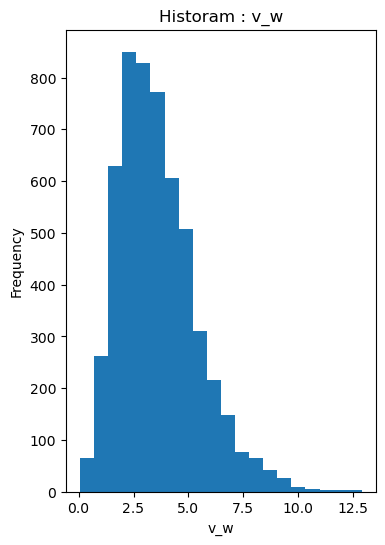

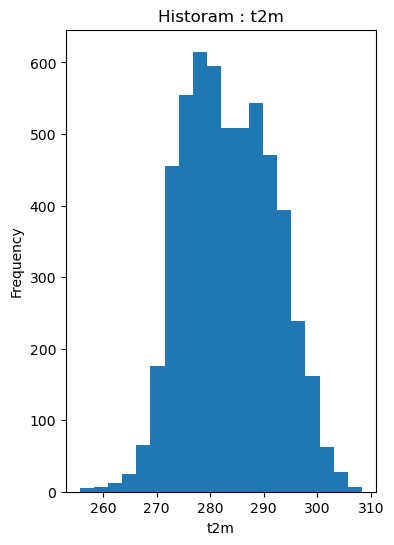

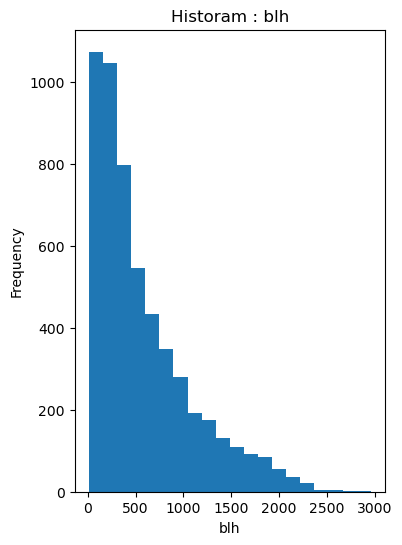

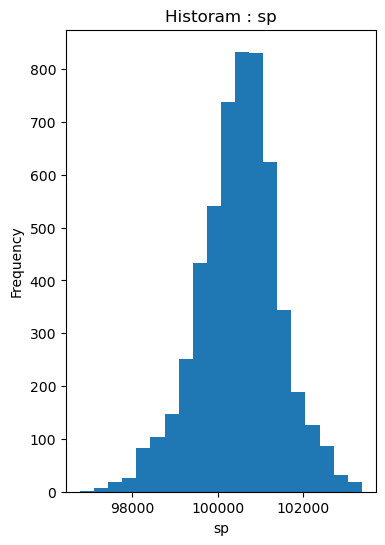

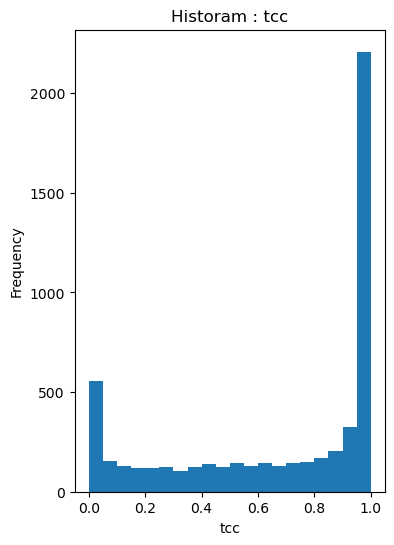

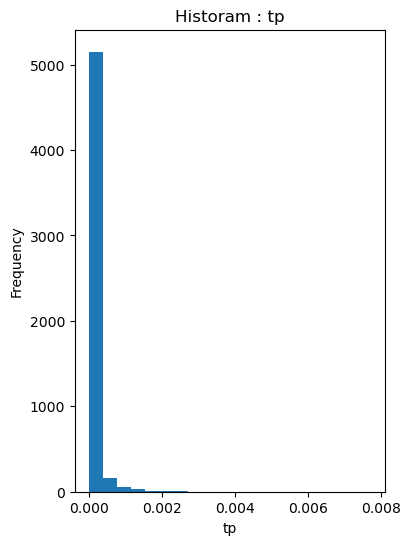

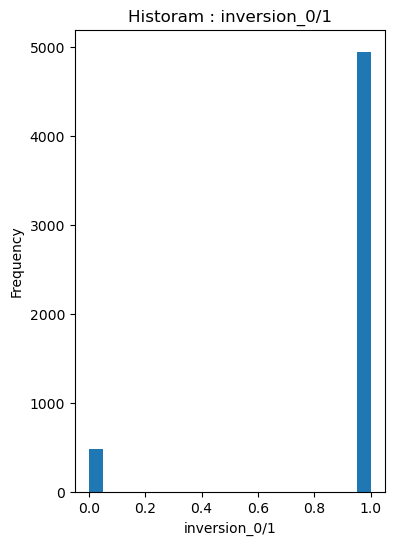

In [610]:
for c in num_col:
    plt.figure(figsize = (4,6))
    plt.hist(pz_main_df[c], bins = 20)
    plt.title(f'Historam : {c}')
    plt.xlabel(c)
    plt.ylabel('Frequency')
    plt.show()
    

In [103]:
# Wartości kolumy 'tp' (całkowitych opadów) charakteryzuja sie ogromna skośnościa,
# zamiamiana na formę binarna uprosci dataset do modelowania 

# Wprowadzamy kolumne 'tp_0/1' - 0 dla obseracji bez opadów, a 1 dla obserwacji gdy był opad

In [612]:
pz_main_df['tp_0/1'] = [0 if e == 0 else 1 for e in pz_main_df['tp']]

In [614]:
# usuwamy niepotrzebna kolumne 'tp'

pz_main_df = pz_main_df.drop('tp', axis=1)

In [616]:
# aktualizujemy num_col
num_col, cat_col = update_columns_ls(pz_main_df)

#### 2.3.3. Analiza Outliery

Wnioski:

Nie usuwam żadnych outlierów, gdyż sa to dane realne , zdobyte zgodnie ze wskazaniami prawidłowo działjacych stacji meteorologicznych.
Każda wartosć będaca poza zakresem IQR to rzeczywiska obserwacja, więc usunięcie ich byłoby fałszowaniem danych.


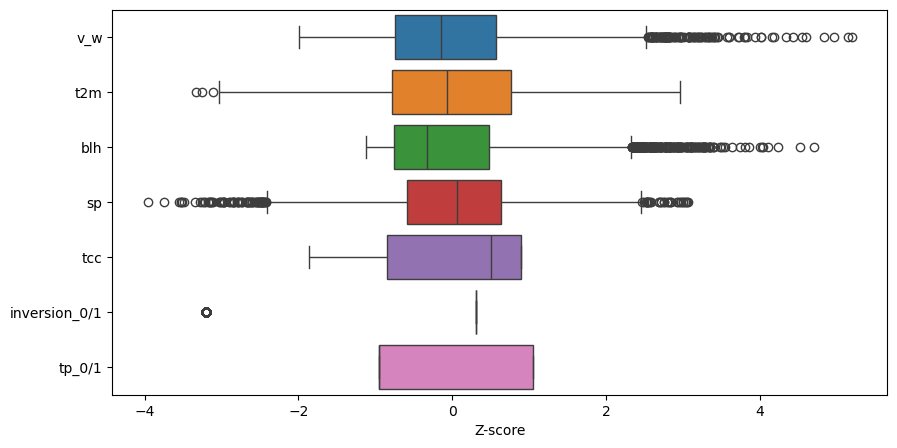

In [618]:
# tworzymy boxplot dla zmiennych z main_df do oceny wizualnej sytuacji outlierów.

num_df = pz_main_df[num_col].copy()

# przy tworzeniu box plot, stosujemy wzrór na Z-sore tj. normalizaja, standaryzacje danych (przeskalownie)
# dla wyraźniejszego pokazania na wykresie rozkładu danych po przez wizualizację statystyk pozycujnych.
plt.figure(figsize=(10,5))
sns.boxplot((num_df-num_df.mean())/num_df.std(),orient='h')
plt.xlabel('Z-score')
plt.show()

#### 2.3.5. Badanie korelacji cech numerycznych PERSONA

Korelacja Pearsona (r)

Definicja: Mierzy siłę i kierunek liniowej zależności między dwiema zmiennymi ilościowymi.

......................................................................................................................................................................................................................................


Wniosek : Z uwagi na wcześniejsza analiza czynników meteorologicznych majacych wpływ na poziom jakości powietrza na danym obszarze,
postanawiam nie usuwać, żednych z wymienionych cech numerycznych.

Ale w badaniu skuteczności modeli moze okazać się , że niektóre dane wymagaja usuniecia 

In [622]:
# corr_matrix = pz_main_df.corr(numeric_only=True,method='pearson')
# corr_target = corr_matrix.loc[num_col,target_col]

In [111]:
# g = sns.PairGrid(main_df['bhl'], hue='PM25')

# # Co ma być na przekątnej (np. rozkład)
# g.map_diag(sns.kdeplot, fill=True)

# # Co ma być nad przekątną (np. wykresy punktowe)
# g.map_upper(sns.scatterplot, s=10)

# # Co ma być pod przekątną (np. wykresy gęstości/regresji)
# g.map_lower(sns.kdeplot, levels=4, color=".2")

# plt.show()

In [626]:
# Korelacja ze zmiennymi cech dla PM10

# corr_target['PM10'].drop(target_col).abs().sort_values(ascending=False).to_frame()

In [113]:
# corr_target['PM25'].drop(target_col).abs().sort_values(ascending=False).to_frame()

In [114]:
# corr_target['NO2'].drop(target_col).abs().sort_values(ascending=False).to_frame()

In [115]:
# corr_target['CO'].drop(target_col).abs().sort_values(ascending=False).to_frame()

#### 2.3.5. Badanie korelacji cech kategorycznych i numerycznych.



Cecha,Pearson,Spearman,ϕk​ (Phi_k)
Typ danych,Tylko liczbowe (ciągłe),Liczbowe / Porządkowe,Mieszane (Liczby + Tekst)
Rodzaj relacji,Tylko liniowa,Monotoniczna (niekoniecznie linia),"Dowolna (nawet ""zygzaki"")"
Wrażliwość na outliery,Bardzo wysoka,Niska,Niska
Kierunek (dodatni/ujemny),Tak,Tak,Nie (tylko siła związku)
Wymagany rozkład normalny,Tak,Nie,Nie

In [628]:
# Współczynnik ϕ 2
# Definicja: Nowoczesny współczynnik oparty na teście χ2
# (Chi-kwadrat). Jest rozszerzeniem współczynnika Craméra V.
# Wartości: od 0 do 1 (nie wskazuje kierunku, tylko siłę związku).
# Przykład: Marka samochodu vs Awaryjność. Tutaj nie ma "kolejności" (marki to kategorie), a Pearson ich nie policzy.
# Kiedy najlepsza: W sytuacjach mieszanych (liczby + tekst) oraz gdy zależności są bardzo skomplikowane (np. sinusoida, gdzie Pearson pokaże 0).

corr_phik = pz_main_df.phik_matrix()


interval columns not set, guessing: ['v_w', 't2m', 'blh', 'sp', 'tcc', 'inversion_0/1', 'tp_0/1']


/opt/anaconda3/lib/python3.12/site-packages/phik/data_quality.py:59: UserWarning: The number of unique values of variable time is large: 5433. Are you sure this is not an interval variable? Analysis for pairs of variables including time can be slow.
  warnings.warn(


<>:15: SyntaxWarning: invalid escape sequence '\p'
<>:15: SyntaxWarning: invalid escape sequence '\p'
/var/folders/1_/28vylhx11cs54zyvgx55gyfw0000gn/T/ipykernel_27692/1165765018.py:15: SyntaxWarning: invalid escape sequence '\p'
  plt.title('Macierz Korelacji $\phi_k$', fontsize=16)


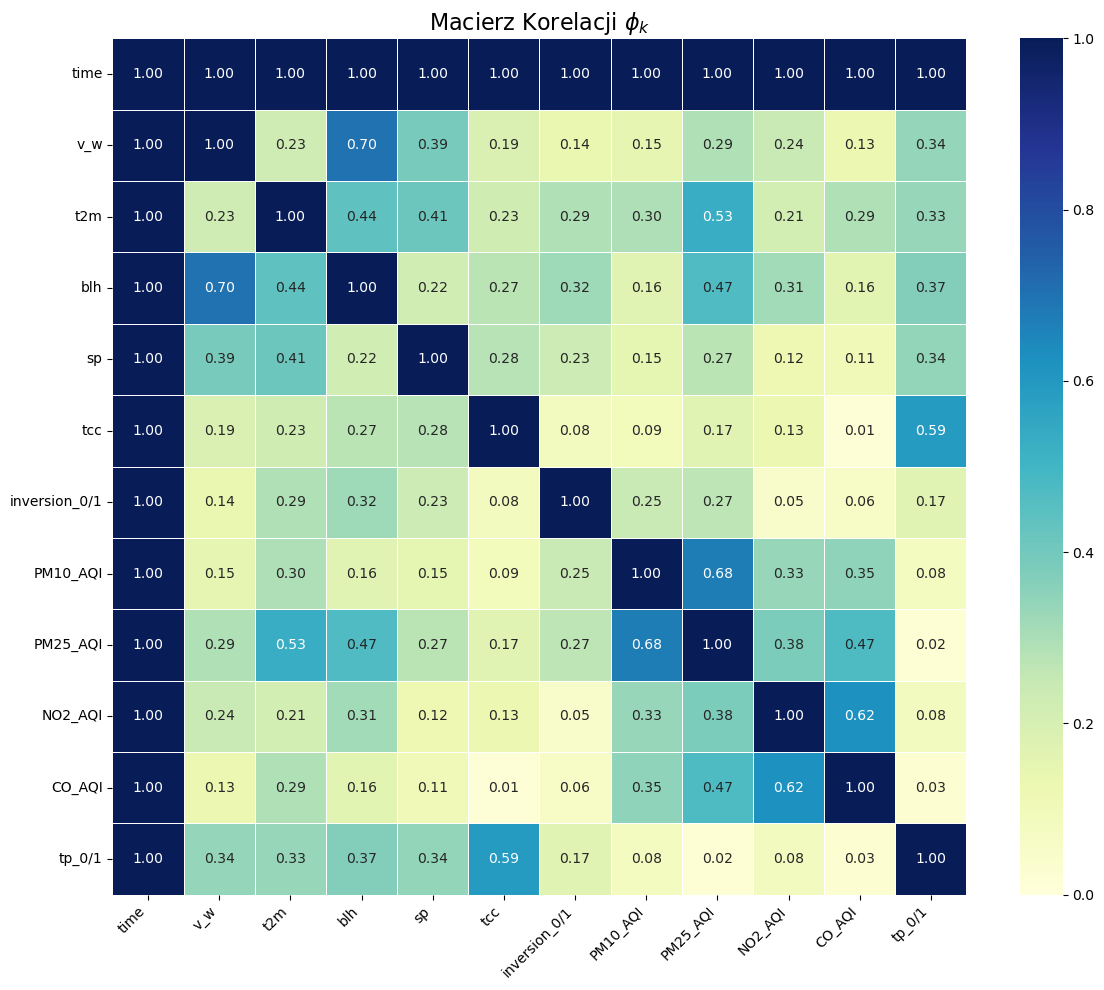

In [629]:
# Wizualizacja macierzy korelacji Phi-kwadrat

plt.figure(figsize = (12,10))
sns.heatmap(
    corr_phik, 
    annot=True,            
    fmt=".2f",            
    cmap='YlGnBu',         
    linewidths=0.5,        
    vmin=0,                
    vmax=1      
)

# 4. Dodanie tytułu i poprawienie czytelności
plt.title('Macierz Korelacji $\phi_k$', fontsize=16)
plt.xticks(rotation=45, ha='right') # Obrócenie nazw kolumn na osi X
plt.tight_layout()

# plt.show()

#### 2.3...... Wnioski / Podsumowanie 

1. Część dancyh cech zmiennych takie jak 
- 'bhl' (wysokość warstwy granicznej) jest 
- 'tp' (całkowite opady)
Prezentuja duża skośnosc rozkładu danych. 
Należy zastostować odpowiednie transformację dla modeli liniowych , numerycznych.
2. Analiza braków danych pokazuje , że najwięcej dancyh brakuje w zmiennych celu :
- PM10 = 239
- PM25 = 239
- NO2 = 176
- CO = 83
- tp = 6
3. Analiza Outlierów pokazuje duże extrema dla kilku dancych meteorologicznych , sa to jednak rzeczywiste pomiary , dla których należy
  zachować wszysktie wartosc.
3.1. Przy mozliwości uzycie redukcji wpływów ekstrmów na działanie modeli, zostana uzyte odpowiednie parametry.


<hr style="height: 25px; background-color: #4e801f; border: none;">

# STEP 3

## 3. Transformacja danych

### 3.1. Feature engeniering

In [632]:

# Rozbijamy 'time' na szczegóły, przypisanie do nowych kolumn wartosći - Rok / Miesiac / Dzień / Dzień_tyg / 
pz_main_df = pz_main_df.assign(
    month=pz_main_df['time'].dt.month_name(),
    year=pz_main_df['time'].dt.year,
    day=pz_main_df['time'].dt.day,
    hour=pz_main_df['time'].dt.time,
    day_of_week=pz_main_df['time'].dt.day_name())


# Po transformacji 'time' na osobne kolumny ta, zmienna nie jest już potrzbena , wiec ja usuwamy.
pz_main_df = pz_main_df.drop('time',axis=1)


# Transformacja kolumna 'hour' z datetime na string
pz_main_df['hour'] = pz_main_df['hour'].astype(str)

In [634]:
# Wprowadzamy kolumnę day_night dla zaznaczenia które pomiary sa noca a które za dania

pz_main_df['is_night'] = ['0' if e in ['00:00:00','06:00:00'] else '1' for e in pz_main_df['hour']]

In [636]:
# Wprowadzamy podział na dzień weekendowy oraz nie weekendowy , dla wskazania wiekszego ruchu drogowego, 
# przy którym wskazania tej samej pogody, moga być inne wskazania jakosci powietrza. 
day_of_weekend = ['Saturday', 'Sunday']

pz_main_df['is_weekend'] = ['1' if e in day_of_weekend else '0' for e in pz_main_df['day_of_week']]

In [638]:
# Ważnym elemntem jest sezonowość pór roku , dlatego prowadzamy nowa kolumne 'season'

season_dic = {
    'sprinig' : ['March','April','May'],
    'summer' : ['June','July','August'],
    'autum' : ['September','October','November'],
    'winter' : ['December','January','February']
}
pz_main_df['season'] = [
    'Winter' if m in ['December','January','February'] else
    'Sprinig' if m in ['March','April','May'] else
    'Summer' if m in ['June','July','August'] else
    'Autum'
    for m in pz_main_df['month']
]

In [692]:
num_col, cat_col = update_columns_ls(pz_main_df)
num_feature_col, cat_feature_col = update_feature_col(pz_main_df)
target_df, feature_df = update_target_feature_df(pz_main_df)

In [696]:
pz_main_df.to_csv('/Users/marcinurbanski/Desktop/merito_projekt_pliki_robocze/pz_main_category.csv')

### 3.2. Podział na X_train, y_train 

In [642]:
# Dzielimy dataset , na część treningowa oraz testowa dla cech oraz celów z pz_main_df

X_train, X_test, y_train, y_test = train_test_split(
    feature_df, target_df,
    test_size=0.2,
    random_state=42
) 

### 3.2. Preprocessing Dla Linear Regression

#### 3.2.1. Standard Scaller 

In [644]:
# Wyznaczmy kolumny do transdormacji dla Linear Regression 
col_to_scale = [x for x in num_feature_col if x != 'inversion_0/1' and x != 'city' and x != 'time']
# dodanie metody jako zmiennej 
num_scaling = StandardScaler()

In [646]:
col_to_scale

['v_w', 't2m', 'blh', 'tp_0/1', 'year', 'day']

#### 3.2.2. Transformacja Logarytmiczna 

In [648]:
# Wyznaczamy nazwy kolumn dla których zastosowana bedzie Transformacja Logarytmiczna , 
# na podstawie analizy wykonanej w punkcie 2.3.1.
skew_ls = skew_df['features'].to_list()
col_to_logtransform = [x for x in num_feature_col if x in skew_ls and x not in target_col]
# dodanie metody jako zmiennej 
num_logtransform =  FunctionTransformer(np.log1p)

In [650]:
col_to_logtransform

['blh']

#### 3.1.3. One hot encoding

In [652]:
col_to_ohe = cat_feature_col
cat_ohe = OneHotEncoder(handle_unknown='ignore')

In [654]:
col_to_ohe

['month', 'hour', 'day_of_week', 'is_night', 'is_weekend', 'season']

### 3.3. Pipeline Preprocesing

#### 3.2.1. Linear Regresion Pipeline 

In [656]:
num_311_313_prepro_LR = Pipeline(steps = [
    ('scaliing' , num_scaling),
])

num_312_prepro_LR  = Pipeline(steps = [
    ('logtrans' , num_logtransform),
])

cat_313_prepro_LR = Pipeline(steps = [
    ('onehot', cat_ohe)
])

### 3.3. Transformacja

#### 3.3.1. Transformacja Kolumn do Linear Regression

In [658]:
lr_transform = ColumnTransformer(transformers=[
    ('num_scaling+fillNaN', num_311_313_prepro_LR ,col_to_scale),
    ('num_logtrans+fillNaN', num_312_prepro_LR, col_to_scale),
    ('cat_onehot', cat_313_prepro_LR, col_to_ohe)
])

lr_transform2 = ColumnTransformer(transformers=[
    ('cat_onehot', cat_313_prepro_LR, col_to_ohe)
])

## 4. Budowanie Modeli ML

### 4.0. Dummy Regresion 

In [151]:
target_col

['PM10', 'PM25', 'NO2', 'CO']

In [662]:
baseline_dr = DummyRegressor()

models_dr = {}

for t in target_col:
    model_dr = baseline_dr.fit(
        X_train, y_train[t],
    )
    preds_dr = model_dr.predict(X_test)
    mae_dr   = mean_absolute_error(y_test[t], preds_dr)
    rmse_dr  = np.sqrt(mean_squared_error(y_test[t], preds_dr))
    r2_dr    = r2_score(y_test[t], preds_dr)

    
    models_dr[t]  = preds_dr
    models_dr[t] = {'MAE': mae_dr, 'RMSE': rmse_dr, 'R2': r2_dr}
    print(f" POLUTION: {t} -> MAE={mae_dr:.3f}  RMSE={rmse_dr:.3f}  R²={r2_dr:.3f}")

ValueError: could not convert string to float: '51-100'

### 4.1. Logistic Regression

#### 4.1.1. Baseline Logistic Regression 
Dla każdeko celu odzielnie 

In [672]:
!pip install -U scikit-learn

In [700]:
# GEMINI WERSJA 

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.multioutput import MultiOutputClassifier
from sklearn.metrics import classification_report, accuracy_score

# ---------------------------------------------------------
# KROK 1: Wczytanie i przygotowanie danych
# ---------------------------------------------------------
# Wczytujemy plik CSV. Opcja index_col=0 usuwa pierwszą kolumnę, jeśli jest to tylko numer wiersza.
# df = pd.read_csv('pz_main_category.csv', index_col=0)

# Definiujemy kolumny docelowe (nasze Y)
target_col = ['PM10_AQI', 'PM25_AQI', 'NO2_AQI', 'CO_AQI']

# Oddzielamy cechy (X) od zmiennych docelowych (y)
X = pz_main_df.drop(columns=target_col)
y = pz_main_df[target_col]

# ---------------------------------------------------------
# KROK 2: Identyfikacja typów kolumn do preprocessingu
# ---------------------------------------------------------
# Wybieramy kolumny numeryczne i kategoryczne
# (Dostosuj listy, jeśli typy danych w pandas wczytają się inaczej)
numeric_features = ['v_w', 't2m', 'blh', 'sp', 'tcc']
categorical_features = ['month', 'year', 'day', 'hour', 'day_of_week', 'season', 'inversion_0/1', 'tp_0/1', 'is_night', 'is_weekend']

# ---------------------------------------------------------
# KROK 3: Podział na zbiór treningowy i testowy
# ---------------------------------------------------------
# Dzielimy dane: 80% do nauki (treningowy), 20% do testów. 
# random_state zapewnia powtarzalność wyników.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# ---------------------------------------------------------
# KROK 4: Budowa transformatora danych (Preprocessing)
# ---------------------------------------------------------
# StandardScaler ustandaryzuje zmienne ciągłe (średnia=0, odchylenie=1)
# OneHotEncoder zamieni kategorie (np. dni tygodnia) na kolumny z zerami i jedynkami
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])

# ---------------------------------------------------------
# KROK 5: Definicja parametrów i stworzenie modelu (Pipeline)
# ---------------------------------------------------------
# Inicjalizujemy regresję logistyczną. 
# Parametry:
# - max_iter=1000: zwiększamy limit iteracji, aby algorytm zdążył zbiec (częsty problem przy złożonych danych).
# - n_jobs=-1: używa wszystkich rdzeni procesora do przyspieszenia obliczeń.
# - class_weight='balanced': pomaga, jeśli masz dużo dni z czystym powietrzem, a mało ze smogiem.
log_reg = LogisticRegression(max_iter=1000, n_jobs=-1, class_weight='balanced')

# Owijamy model w MultiOutputClassifier, aby obsłużył 4 kolumny targetu na raz.
multi_target_model = MultiOutputClassifier(log_reg, n_jobs=-1)

# Tworzymy ostateczny Pipeline (Rurociąg), który najpierw przekształca dane, a potem uczy model
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', multi_target_model)
])

# ---------------------------------------------------------
# KROK 6: Trening modelu i Predykcja
# ---------------------------------------------------------
print("Rozpoczynam trenowanie modelu...")
pipeline.fit(X_train, y_train)
print("Trenowanie zakończone.\n")

# Wykonujemy przewidywania na zbiorze testowym, którego model nigdy wcześniej nie widział
y_pred = pipeline.predict(X_test)

# Zamieniamy tablicę numpy z powrotem na DataFrame dla łatwiejszego przetwarzania
y_pred_df = pd.DataFrame(y_pred, columns=target_col)

# ---------------------------------------------------------
# KROK 7: Ewaluacja modelu (Metryki)
# ---------------------------------------------------------
print("=== WYNIKI EWALUACJI MODELU ===")

# Sprawdzamy wyniki osobno dla każdej z 4 kolumn docelowych
for col in target_col:
    print(f"\n--- Raport Klasyfikacji dla: {col} ---")
    
    # Accuracy - jaki procent przewidywań był ogólnie poprawny
    acc = accuracy_score(y_test[col], y_pred_df[col])
    print(f"Dokładność (Accuracy): {acc:.4f}")
    
    # Classification report - szczegółowe metryki dla każdej klasy (0-50, 51-100 itd.)
    report = classification_report(y_test[col], y_pred_df[col], zero_division=0)
    print(report)

Rozpoczynam trenowanie modelu...


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)
/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)
/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)
/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
 

Trenowanie zakończone.

=== WYNIKI EWALUACJI MODELU ===

--- Raport Klasyfikacji dla: PM10_AQI ---
Dokładność (Accuracy): 0.8077
              precision    recall  f1-score   support

        0-50       0.99      0.81      0.89      1039
     151-200       0.00      0.00      0.00         0
      51-100       0.15      0.73      0.25        48

    accuracy                           0.81      1087
   macro avg       0.38      0.51      0.38      1087
weighted avg       0.95      0.81      0.86      1087


--- Raport Klasyfikacji dla: PM25_AQI ---
Dokładność (Accuracy): 0.5833
              precision    recall  f1-score   support

        0-50       0.74      0.69      0.72       539
     101-150       0.21      0.50      0.30        68
     151-200       0.26      0.79      0.39        19
     201-300       0.00      0.00      0.00         0
      51-100       0.58      0.46      0.51       461

    accuracy                           0.58      1087
   macro avg       0.36      0.49    

In [680]:
baseline_lr = Pipeline([
    ('preprocess', lr_transform),
    ('model', model_lr)
])

In [686]:
baseline_lr.fit(X_train, y_train)

ValueError: Specifying the columns using strings is only supported for dataframes.

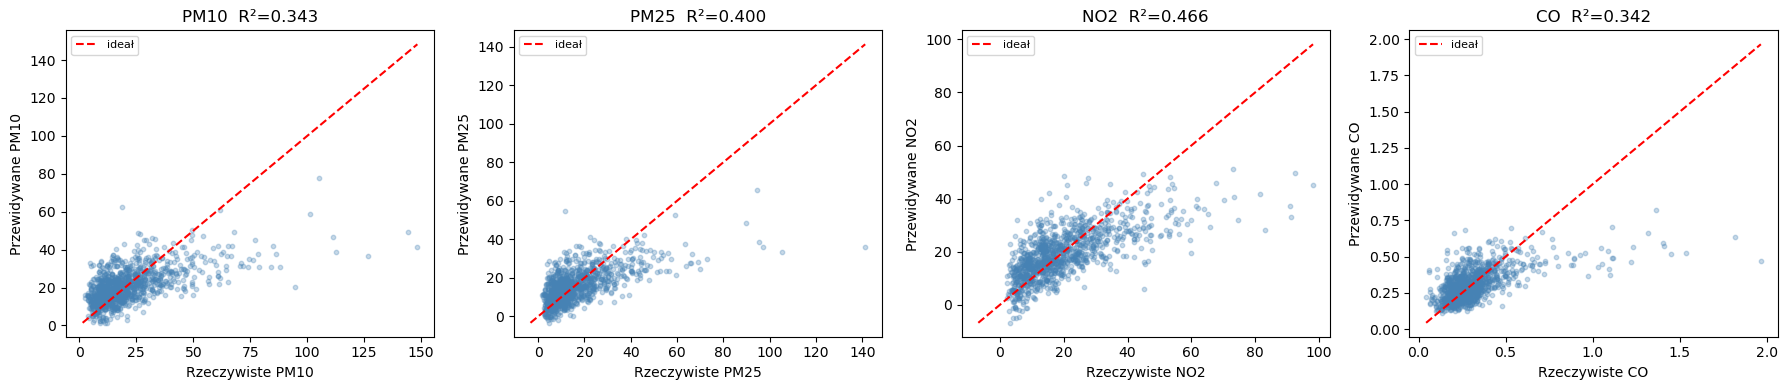

In [162]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for i, col in enumerate(target_col):
    y_t = y_test[col].values
    y_p = y_pred_lr[:, i]
    axes[i].scatter(y_t, y_p, alpha=0.3, s=10, color='steelblue')
    lim = [min(y_t.min(), y_p.min()), max(y_t.max(), y_p.max())]
    axes[i].plot(lim, lim, 'r--', linewidth=1.5, label='ideał')
    axes[i].set_xlabel(f'Rzeczywiste {col}')
    axes[i].set_ylabel(f'Przewidywane {col}')
    axes[i].set_title(f'{col}  R²={r2_score(y_t,y_p):.3f}')
    axes[i].legend(fontsize=8)
plt.tight_layout()
plt.show()

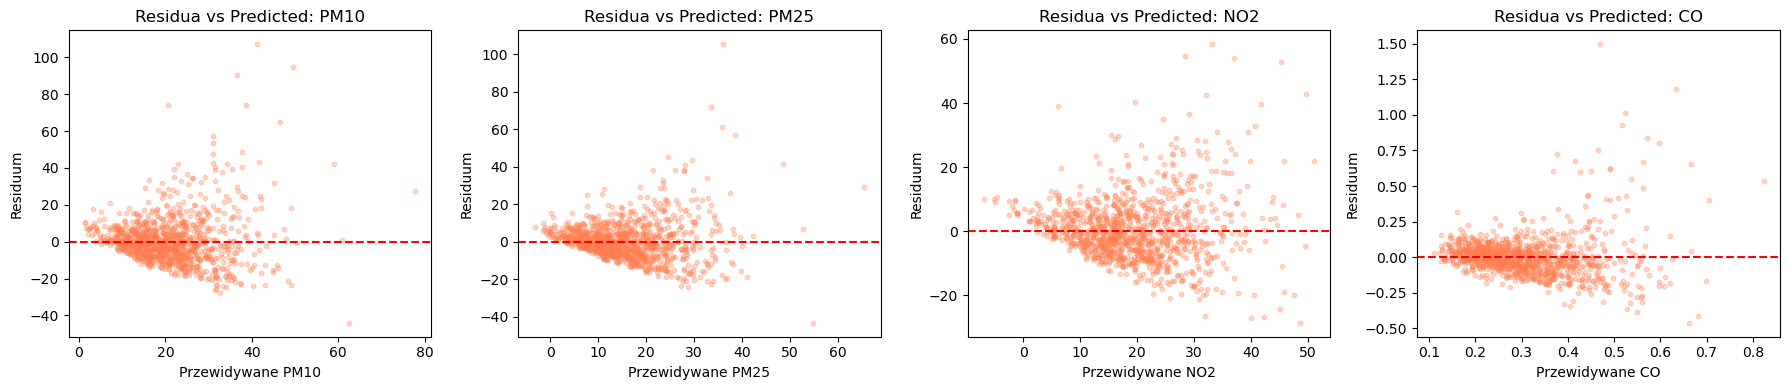

In [163]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for i, col in enumerate(target_col):
    y_p = y_pred_lr[:, i]
    residuals = y_test[col].values - y_p
    axes[i].scatter(y_p, residuals, alpha=0.3, s=10, color='coral')
    axes[i].axhline(0, color='red', linestyle='--', linewidth=1.5)
    axes[i].set_xlabel(f'Przewidywane {col}')
    axes[i].set_ylabel('Residuum')
    axes[i].set_title(f'Residua vs Predicted: {col}')
plt.tight_layout()
plt.show()

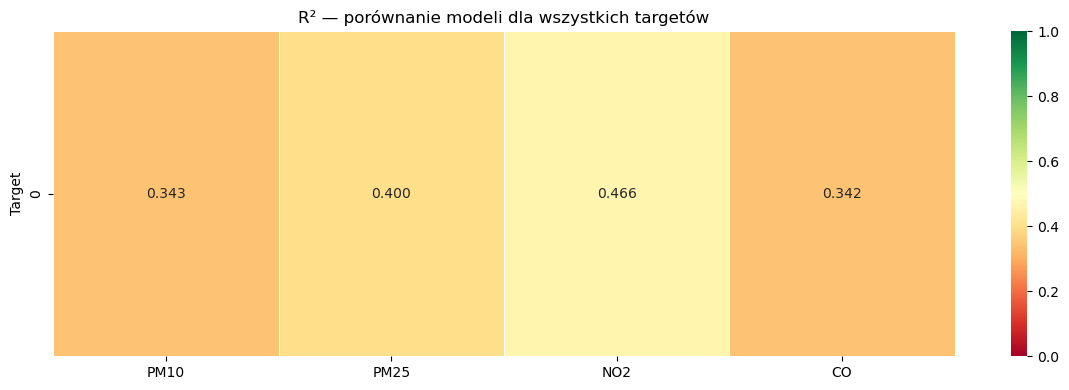

In [164]:
r2_matrix = pd.DataFrame({
    name: df['R2'] for name, df in results.items()
},index=[0])
plt.figure(figsize=(12, 4))
sns.heatmap(r2_matrix, annot=True, fmt='.3f', cmap='RdYlGn',
            vmin=0, vmax=1, linewidths=0.5)
plt.title('R² — porównanie modeli dla wszystkich targetów')
plt.ylabel('Target')
plt.tight_layout()
plt.show()

### 4.2. CatBoost

#### 4.2.1. Baseline_CB 

In [704]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
from catboost import CatBoostClassifier

# ---------------------------------------------------------
# KROK 1: Wczytanie i przygotowanie danych
# ---------------------------------------------------------
# Wczytujemy plik CSV. Opcja index_col=0 usuwa nienazwaną pierwszą kolumnę z indeksami wierszy.
# df = pd.read_csv('pz_main_category.csv', index_col=0)

# Definiujemy listę czterech kolumn docelowych (nasz target)
target_cols = ['PM10_AQI', 'PM25_AQI', 'NO2_AQI', 'CO_AQI']

# Oddzielamy cechy wejściowe (X) od zmiennych, które chcemy przewidzieć (y)
X = pz_main_df.drop(columns=target_cols)
y = pz_main_df[target_cols]

# ---------------------------------------------------------
# KROK 2: Przygotowanie zmiennych kategorycznych
# ---------------------------------------------------------
# Jedną z największych zalet CatBoost jest to, że NIE potrzebuje on OneHotEncodera.
# Musimy mu jednak jawnie wskazać, które kolumny reprezentują kategorie tekstowe lub porządki czasowe.
categorical_features = [
    'month', 'year', 'day', 'hour', 'day_of_week', 
    'season', 'inversion_0/1', 'tp_0/1', 'is_night', 'is_weekend'
]

# Konwertujemy wybrane kolumny na typ tekstowy (string). 
# Zapobiega to sytuacji, w której CatBoost potraktowałby np. rok 2024 jako ciągłą liczbę matematyczną.
for col in categorical_features:
    X[col] = X[col].astype(str)

# ---------------------------------------------------------
# KROK 3: Podział na zbiór treningowy i testowy
# ---------------------------------------------------------
# Dzielimy dane w stosunku 80% do nauki i 20% do końcowego testu.
# random_state=42 gwarantuje, że przy każdym uruchomieniu podział będzie dokładnie taki sam.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Tworzymy puste słowniki, w których zapiszemy wyniki i modele dla każdej z 4 substancji
models = {}
predictions = {}

# ---------------------------------------------------------
# KROK 4: Pętla trenująca osobne modele dla każdej substancji
# ---------------------------------------------------------
for target in target_cols:
    print(f"\n" + "="*60)
    print(f"ROZPOCZYNAM TRENOWANIE MODELU DLA: {target}")
    print("="*60)
    
    # Inicjalizacja klasyfikatora CatBoost z kluczowymi parametrami:
    # - iterations=600: Model wybuduje sekwencyjnie 600 drzew decyzyjnych.
    # - learning_rate=0.05: Szybkość uczenia – mniejsza wartość zapobiega przeuczeniu (overfitting).
    # - depth=6: Maksymalna głębokość pojedynczego drzewa (optymalny standard).
    # - auto_class_weights='Balanced': KLUCZOWY PARAMETR. Automatycznie zwiększa wagę rzadkich klas 
    #   (np. 100-150), zmuszając algorytm do ich dokładnego wykrywania i podnosząc F1-score.
    # - cat_features: Przekazujemy listę nazw naszych kolumn kategorycznych.
    # - verbose=100: Informuje nas o postępach i błędzie (Loss) co 100 wybudowanych drzew.
    model = CatBoostClassifier(
        iterations=600,
        learning_rate=0.05,
        depth=6,
        auto_class_weights='Balanced',
        cat_features=categorical_features,
        verbose=100,
        random_seed=42
    )
    
    # Proces dopasowania (trenowania) modelu do danych historycznych
    # Podajemy całe X_train (pogoda), ale tylko jedną konkretną kolumnę z y_train.
    model.fit(X_train, y_train[target])
    
    # Zapisujemy gotowy model w naszym słowniku, by móc go użyć w przyszłości
    models[target] = model
    
    # Model na podstawie danych pogodowych z X_test próbuje odgadnąć poziomy zanieczyszczeń
    predictions[target] = model.predict(X_test)

# ---------------------------------------------------------
# KROK 5: Generowanie raportów i ewaluacja metryk
# ---------------------------------------------------------
print("\n\n" + "#"*60)
# Po zakończeniu pętli przechodzimy do wyświetlenia rezultatów dla każdej substancji
print("### KOŃCOWE WYNIKI MODELU CATBOOST ###")
print("#"*60)

for target in target_cols:
    print(f"\n--- RAPORT KLASYFIKACJI DLA: {target} ---")
    
    # Liczymy ogólną celność modelu
    acc = accuracy_score(y_test[target], predictions[target])
    print(f"Ogólna dokładność (Accuracy): {acc:.4f}\n")
    
    # Generujemy szczegółowy raport (Precision, Recall, F1-score dla KAŻDEJ klasy osobno)
    # Parametr zero_division=0 zapobiega błędom dzielenia przez zero, gdyby jakaś klasa w ogóle nie wystąpiła
    report = classification_report(y_test[target], predictions[target], zero_division=0)
    print(report)


ROZPOCZYNAM TRENOWANIE MODELU DLA: PM10_AQI
0:	learn: 1.3555198	total: 401ms	remaining: 4m
100:	learn: 0.6500872	total: 20.5s	remaining: 1m 41s
200:	learn: 0.2429214	total: 50.6s	remaining: 1m 40s
300:	learn: 0.1045831	total: 1m 22s	remaining: 1m 22s
400:	learn: 0.0733277	total: 2m 1s	remaining: 1m
500:	learn: 0.0577130	total: 2m 28s	remaining: 29.4s
599:	learn: 0.0487133	total: 2m 58s	remaining: 0us

ROZPOCZYNAM TRENOWANIE MODELU DLA: PM25_AQI
0:	learn: 1.6094379	total: 104ms	remaining: 1m 2s
100:	learn: 0.7890574	total: 35.4s	remaining: 2m 54s
200:	learn: 0.5511331	total: 1m 20s	remaining: 2m 40s
300:	learn: 0.4136321	total: 2m 7s	remaining: 2m 6s
400:	learn: 0.3425207	total: 2m 55s	remaining: 1m 27s
500:	learn: 0.3012023	total: 3m 37s	remaining: 43s
599:	learn: 0.2739306	total: 4m 22s	remaining: 0us

ROZPOCZYNAM TRENOWANIE MODELU DLA: NO2_AQI
0:	learn: 1.0710566	total: 399ms	remaining: 3m 59s
100:	learn: 0.4998195	total: 20.2s	remaining: 1m 39s
200:	learn: 0.3073750	total: 42.8s	re

# SPRAWDZENIA 

In [169]:
# X_train.isna().sum()

In [170]:
# (main_df[feature_col]<0).any()

In [171]:
# y_train.isna().sum()

In [172]:
# main_df['inversion_0/1'].unique()
# main_df['inversion_0/1'].isna().sum()